# Forecasting de Demanda no Varejo com Prophet

**Autores:** Daniel Gallo de Almeida Junior e Tiago Sousa Leite  
**Contexto:** projeto acadêmico — FIAP  
**Dataset:** `retail_price.csv`  
**Produto modelado:** `bed2`  

> Notebook com análise, código, gráficos e respostas às 18 questões do estudo.


## Configuracao e carga dos dados

In [1]:
from pathlib import Path
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from prophet import Prophet


def find_project_root(start=Path.cwd()):
    """Locate the project whether Jupyter starts at the root or notebooks/."""
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'retail_price.csv').exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data/retail_price.csv. Start Jupyter inside the project."
    )


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / 'data' / 'retail_price.csv'

np.random.seed(42)
df = pd.read_csv(DATA_PATH)
df['month_year'] = pd.to_datetime(df['month_year'], format='%d-%m-%Y')
df.shape


C:\Users\tsous\AppData\Local\Temp\codex-portfolio-validation\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


(676, 30)

## Parte 1 - Entendimento do problema

### Questao 1 - Definicao do problema

A variavel-alvo e **`qty`**, a quantidade de unidades vendidas por produto. Ela e mais adequada para estoque e compras do que receita, pois corresponde diretamente a unidades fisicas. O forecast deve ser **mensal**, porque `month_year` possui uma observacao no primeiro dia de cada mes.

### Questao 2 - Granularidade

O dataset contem 52 produtos, portanto 52 series potenciais. Ordenar tudo por data e entregar `qty` ao Prophet misturaria demandas de produtos diferentes na mesma serie. Uma **serie temporal unica** acompanha uma entidade com significado consistente de `y`; **multiplas series temporais** exigem um modelo por produto ou uma agregacao de negocio explicitamente definida.

In [2]:
product_summary = (df.groupby('product_id')
  .agg(observations=('qty','size'), total_qty=('qty','sum'), start=('month_year','min'),
       end=('month_year','max'), months=('month_year','nunique'), unique_prices=('unit_price','nunique'))
  .reset_index())
product_summary['expected_months'] = product_summary.apply(
    lambda r: (r['end'].to_period('M') - r['start'].to_period('M')).n + 1, axis=1)
product_summary['gaps'] = product_summary['expected_months'] - product_summary['months']
q1, q3 = df['qty'].quantile([.25,.75])
outlier_limit = q3 + 1.5*(q3-q1)
print(f'Dimensao: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Produtos: {df.product_id.nunique()} | Categorias: {df.product_category_name.nunique()} | Meses: {df.month_year.nunique()}')
print(f'Nulos: {df.isna().sum().sum()} | Duplicatas produto-mes: {df.duplicated(["product_id","month_year"]).sum()}')
print(f'Lacunas internas: {product_summary.gaps.sum()} meses em {(product_summary.gaps>0).sum()} produtos')
print(f'Outliers qty: {(df.qty>outlier_limit).sum()} acima de {outlier_limit:.0f}')

Dimensao: 676 linhas x 30 colunas
Produtos: 52 | Categorias: 9 | Meses: 20
Nulos: 0 | Duplicatas produto-mes: 0
Lacunas internas: 39 meses em 23 produtos
Outliers qty: 42 acima de 39


### Questao 3 - Qualidade dos dados

- **Cobertura curta e desigual:** 676 linhas e apenas 20 meses; produtos tem de 5 a 20 observacoes.
- **Lacunas:** 23 produtos somam 39 meses ausentes, que podem representar zero venda, indisponibilidade ou falha de coleta.
- **Outliers:** 42 valores (6.2%) superam 39 unidades pelo criterio IQR e podem puxar a tendencia.
- **Preco:** 50 de 52 produtos mudaram de preco; o modelo univariado nao isola esse efeito.
- Nao ha nulos, duplicatas produto-mes ou vendas iguais a zero, mas meses sem linha ainda precisam de validacao de negocio.

## Parte 2 - Construcao do forecast

Produto: bed2 | Periodo: 2017-02-01 a 2018-08-01
Observacoes: 19 | Treino: 15 | Teste: 4


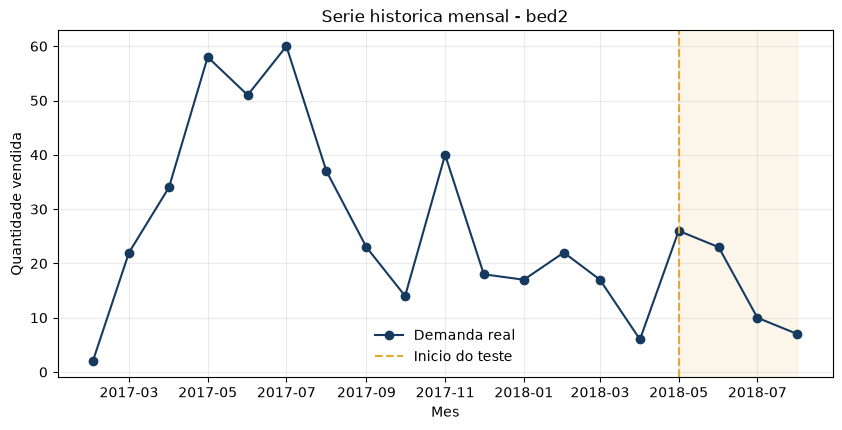

In [3]:
serie = (df.loc[df.product_id.eq('bed2'), ['month_year','qty']]
         .rename(columns={'month_year':'ds','qty':'y'})
         .sort_values('ds').reset_index(drop=True))
split = math.floor(len(serie)*0.80)
treino, teste = serie.iloc[:split].copy(), serie.iloc[split:].copy()
print(f'Produto: bed2 | Periodo: {serie.ds.min().date()} a {serie.ds.max().date()}')
print(f'Observacoes: {len(serie)} | Treino: {len(treino)} | Teste: {len(teste)}')
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(serie.ds, serie.y, marker='o', color='#163A5F', label='Demanda real')
ax.axvline(teste.ds.iloc[0], color='#E5A832', ls='--', label='Inicio do teste')
ax.axvspan(teste.ds.iloc[0], teste.ds.iloc[-1], color='#E5A832', alpha=.10)
ax.set(title='Serie historica mensal - bed2', xlabel='Mes', ylabel='Quantidade vendida')
ax.grid(alpha=.25); ax.legend(frameon=False); plt.show()

### Questoes 4 e 5 - Selecao e preparacao

Escolhi **bed2** por possuir 19 meses consecutivos, sem lacunas, e 487 unidades vendidas - maior volume entre as series longas e continuas. A serie foi preparada com `ds = month_year` e `y = qty`, de fev/2017 a ago/2018.

### Questao 6 - Treino e teste

Usei os 15 primeiros meses para treino (78,9%) e os 4 ultimos para teste (21,1%). A divisao aleatoria causaria vazamento temporal ao usar o futuro para prever o passado; a divisao cronologica simula a operacao real.

13:41:06 - cmdstanpy - INFO - Chain [1] start processing


13:41:07 - cmdstanpy - INFO - Chain [1] done processing


           ds   y   yhat  yhat_lower  yhat_upper  erro
15 2018-05-01  26  16.98         0.0       37.67 -9.02
16 2018-06-01  23  15.56         0.0       37.11 -7.44
17 2018-07-01  10  14.19         0.0       35.92  4.19
18 2018-08-01   7  12.77         0.0       33.33  5.77


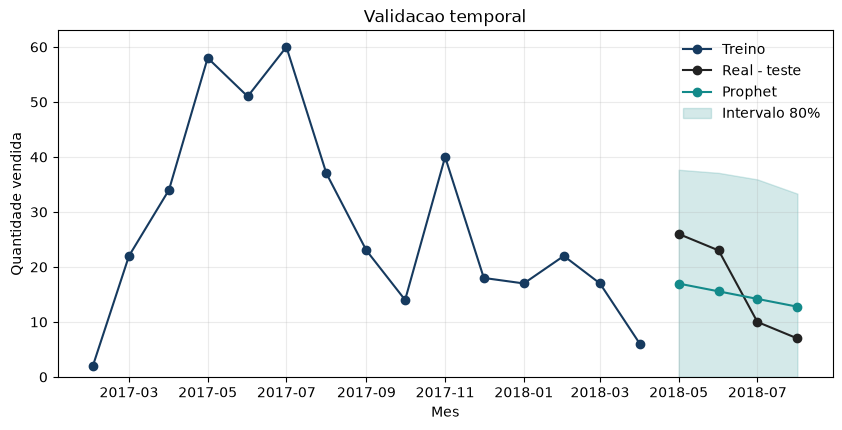

In [4]:
modelo = Prophet(interval_width=.80, yearly_seasonality=False,
                  weekly_seasonality=False, daily_seasonality=False)
modelo.fit(treino)
np.random.seed(42)
prev_teste = modelo.predict(teste[['ds']])
resultado_teste = teste.copy()
resultado_teste['yhat'] = prev_teste['yhat'].to_numpy()
resultado_teste['yhat_lower'] = prev_teste['yhat_lower'].clip(lower=0).to_numpy()
resultado_teste['yhat_upper'] = prev_teste['yhat_upper'].to_numpy()
resultado_teste['erro'] = resultado_teste['yhat'] - resultado_teste['y']
print(resultado_teste.round(2))
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(treino.ds, treino.y, marker='o', color='#163A5F', label='Treino')
ax.plot(resultado_teste.ds, resultado_teste.y, marker='o', color='#222222', label='Real - teste')
ax.plot(resultado_teste.ds, resultado_teste.yhat, marker='o', color='#138A8A', label='Prophet')
ax.fill_between(resultado_teste.ds, resultado_teste.yhat_lower, resultado_teste.yhat_upper, color='#138A8A', alpha=.18, label='Intervalo 80%')
ax.set(title='Validacao temporal', xlabel='Mes', ylabel='Quantidade vendida', ylim=(0,None))
ax.grid(alpha=.25); ax.legend(frameon=False)
figure_path = PROJECT_ROOT / 'reports' / 'figures' / 'temporal-validation.svg'
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, bbox_inches='tight')
plt.show()

### Questao 7 - Forecast

O Prophet usa tendencia linear e intervalo de 80%. Desabilitei sazonalidades diaria/semanal pela frequencia mensal e anual pela falta de dois ciclos completos. O horizonte futuro e de **3 meses**, adequado a planejamento de curto prazo com somente 19 pontos. Limites negativos foram truncados em zero apenas na comunicacao operacional.

## Parte 3 - Avaliacao do modelo

In [5]:
def metricas(real, previsto):
    real, previsto = np.asarray(real,float), np.asarray(previsto,float)
    return {'MAE': np.mean(np.abs(real-previsto)),
            'RMSE': np.sqrt(np.mean((real-previsto)**2)),
            'MAPE': np.mean(np.abs((real-previsto)/real))*100,
            'sMAPE': np.mean(2*np.abs(real-previsto)/(np.abs(real)+np.abs(previsto)))*100}
comparacao = pd.DataFrame([
 {'modelo':'Prophet', **metricas(teste.y, resultado_teste.yhat)},
 {'modelo':'Baseline - ultimo valor', **metricas(teste.y, np.repeat(treino.y.iloc[-1], len(teste)))},
 {'modelo':'Baseline - media do treino', **metricas(teste.y, np.repeat(treino.y.mean(), len(teste)))}])
comparacao.round(2)

,modelo,MAE,RMSE,MAPE,sMAPE
0,Prophet,6.61,6.85,47.85,43.40
1,Baseline - ultimo valor,10.50,13.29,51.28,76.91
2,Baseline - media do treino,11.57,14.14,127.90,60.64


### Questao 8 - Metricas

O Prophet obteve **MAE 6.61**, **RMSE 6.85**, **MAPE 47.85%** e **sMAPE 43.40%**. Superou os baselines em erro absoluto, mas o percentual e alto, o teste tem apenas quatro meses e os valores reais sao pequenos. E um sinal direcional, nao um modelo confiavel para compras automaticas.

           ds   y   yhat  erro
15 2018-05-01  26  16.98 -9.02
16 2018-06-01  23  15.56 -7.44
17 2018-07-01  10  14.19  4.19
18 2018-08-01   7  12.77  5.77


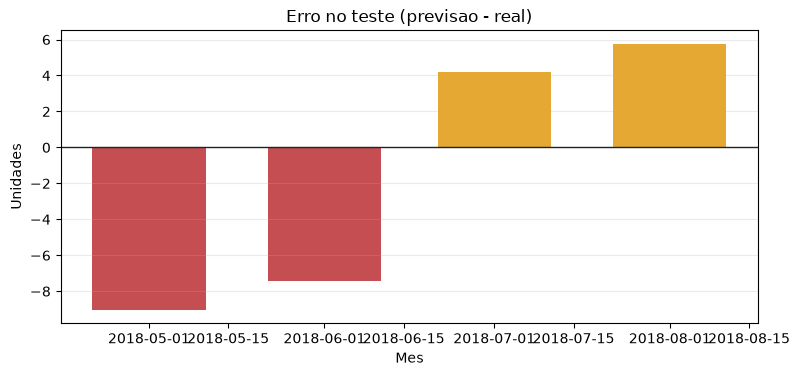

In [6]:
print(resultado_teste[['ds','y','yhat','erro']].round(2))
cores = ['#C44E52' if e < 0 else '#E5A832' for e in resultado_teste.erro]
fig, ax = plt.subplots(figsize=(9,3.8))
ax.bar(resultado_teste.ds, resultado_teste.erro, width=20, color=cores)
ax.axhline(0, color='#222222', lw=1)
ax.set(title='Erro no teste (previsao - real)', xlabel='Mes', ylabel='Unidades')
ax.grid(axis='y', alpha=.25); plt.show()

### Questao 9 - Erro do modelo

O modelo subestimou mai/2018 (-9,02) e jun/2018 (-7,44) e superestimou jul/2018 (+4,19) e ago/2018 (+5,77). O padrao sugere atraso da tendencia suave para reagir a uma mudanca de nivel. Nao parece totalmente aleatorio, mas quatro pontos nao permitem uma conclusao forte; seria necessario backtesting com mais janelas.

### Questao 10 - Forecast nao e certeza

Nao se deve comprar exatamente 120 unidades. A previsao pontual e o centro; 75-180 representa incerteza. A compra deve descontar estoque disponivel e pedidos em transito e incluir estoque de seguranca conforme lead time, nivel de servico, custo de ruptura e custo de excesso. O forecast apoia a decisao; nao e uma ordem de compra.

## Parte 4 - Interpretacao do Prophet

13:41:10 - cmdstanpy - INFO - Chain [1] start processing


13:41:10 - cmdstanpy - INFO - Chain [1] done processing


           ds   yhat  yhat_lower_operational  yhat_upper
19 2018-09-01  12.09                     0.0       30.97
20 2018-10-01  10.75                     0.0       29.28
21 2018-11-01   9.37                     0.0       29.24


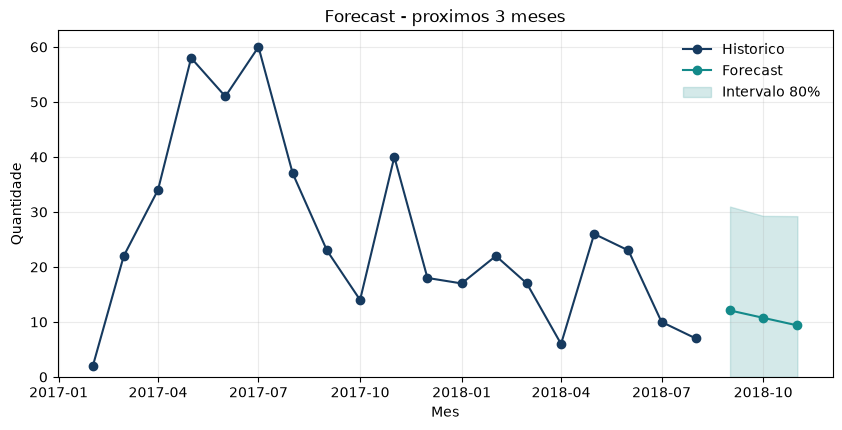

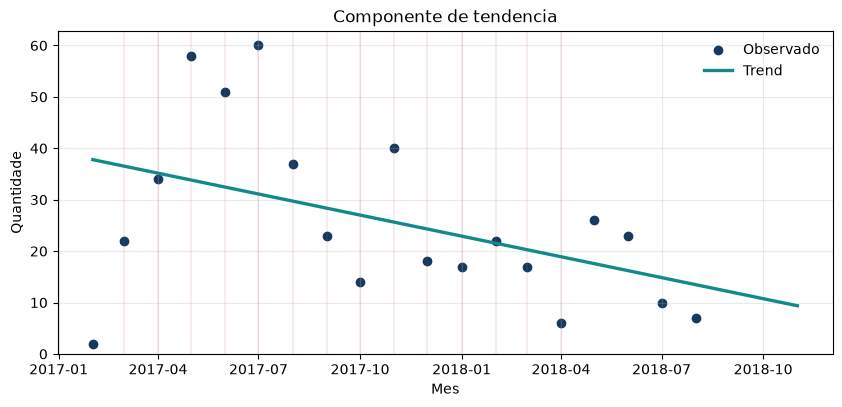

In [7]:
modelo_final = Prophet(interval_width=.80, yearly_seasonality=False,
                        weekly_seasonality=False, daily_seasonality=False)
modelo_final.fit(serie)
futuro = modelo_final.make_future_dataframe(periods=3, freq='MS')
np.random.seed(42)
forecast = modelo_final.predict(futuro)
forecast['yhat_lower_operational'] = forecast.yhat_lower.clip(lower=0)
prev_futura = forecast.loc[forecast.ds > serie.ds.max()].copy()
print(prev_futura[['ds','yhat','yhat_lower_operational','yhat_upper']].round(2))
fig, ax = plt.subplots(figsize=(10,4.5))
ax.plot(serie.ds, serie.y, marker='o', color='#163A5F', label='Historico')
ax.plot(prev_futura.ds, prev_futura.yhat, marker='o', color='#138A8A', label='Forecast')
ax.fill_between(prev_futura.ds, prev_futura.yhat_lower_operational, prev_futura.yhat_upper, color='#138A8A', alpha=.18, label='Intervalo 80%')
ax.set(title='Forecast - proximos 3 meses', xlabel='Mes', ylabel='Quantidade', ylim=(0,None))
ax.grid(alpha=.25); ax.legend(frameon=False)
figure_path = PROJECT_ROOT / 'reports' / 'figures' / 'three-month-forecast.svg'
figure_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(figure_path, bbox_inches='tight')
plt.show()
fig, ax = plt.subplots(figsize=(10,4.2))
ax.scatter(serie.ds, serie.y, color='#163A5F', label='Observado')
ax.plot(forecast.ds, forecast.trend, color='#138A8A', lw=2.4, label='Trend')
for cp in modelo_final.changepoints: ax.axvline(cp, color='#C44E52', alpha=.10)
ax.set(title='Componente de tendencia', xlabel='Mes', ylabel='Quantidade', ylim=(0,None))
ax.grid(alpha=.25); ax.legend(frameon=False); plt.show()

### Questao 11 - Tendencia

A tendencia e decrescente: aproximadamente 37.8 no inicio, 13.5 em ago/2018 e 9.4 em nov/2018. A direcao estimada e suave, mas os dados sao volateis. A media dos seis primeiros meses e 37.8, contra 14.8 nos seis ultimos.

### Questao 12 - Sazonalidade

Nao ha evidencia suficiente. Sao apenas 19 meses no total e 15 no treino, menos de dois ciclos anuais; dados mensais nao sustentam sazonalidade diaria ou semanal. O modelo final nao inclui componente sazonal, evitando confundir oscilacao com repeticao confiavel.

### Questao 13 - Changepoints

Os deltas de inclinacao foram praticamente nulos (maior |delta| = 0.000000), sem changepoint relevante. Mesmo se detectado, um ponto pode refletir promocao/preco temporario, ruptura de estoque, falha de coleta, concorrencia ou outlier. E necessario cruzar a data com dados operacionais antes de interpreta-la como mudanca real.

### Questao 14 - Dados versus modelo

Nao confiaria em um forecast com cinco observacoes. Quase nao ha dados para teste, nao ha base para sazonalidade e o modelo pode apenas interpolar ruido. A previsao seria exploratoria, comparada a um baseline e acompanhada de intervalos amplos ate obter mais historico.

## Parte 5 - IA como ferramenta

### Questao 15 - Auditoria do codigo gerado por IA

Auditei e corrigi: (1) alvo `qty` e uma serie por produto; (2) parsing dia-mes-ano e frequencia `MS`; (3) corte cronologico, nao aleatorio; (4) sazonalidades desabilitadas por insuficiencia de ciclos; (5) horizonte limitado a 3 meses; (6) tratamento transparente de limites negativos; e (7) avaliacao com varias metricas e baselines. Essas decisoes mudam diretamente a validade do resultado.

### Questao 16 - Alucinacao da IA

Uma IA poderia afirmar sem evidencia que a queda de preco aumentara a demanda, que havera uma promocao ou que existe sazonalidade positiva. O forecast real de bed2 aponta queda e nao prova causalidade de preco. Eu verificaria essas hipoteses com mais historico, calendario promocional, estoque/rupturas, precos futuros, backtesting e, para elasticidade, analise causal ou experimento.

## Parte 6 - Case executivo (cenario hipotetico bed1)

### Questao 17 - Recomendacao executiva

Preparar capacidade adicional, mas aumentar o estoque de forma moderada e em etapas. Usar 135 como cenario base, 90 como conservador e 190 como alta demanda, ajustando por estoque atual, pedidos em transito, lead time e nivel de servico. Preferir reposicoes frequentes ou pedido flexivel e acompanhar vendas, cobertura e ruptura semanalmente, com gatilhos para acelerar ou cancelar compras. MAE 22, MAPE 18% e intervalo amplo impedem um grande lote automatico.

### Questao 18 - Decisao sob incerteza

Forecasting reduz, mas nao elimina incerteza. Concorrencia, preco, promocao, renda, ruptura e fornecedor podem mudar a demanda. Aumentar muito o estoque pode gerar capital parado, armazenagem e obsolescencia. A politica deve combinar forecast, margem, custo de falta/excesso, lead time e nivel de servico: o modelo informa o risco, a empresa decide quanto aceitar.

## Conclusao

Para bed2, o Prophet indica queda de curto prazo e supera baselines simples em MAE/RMSE, mas o historico curto e o erro percentual elevado limitam a decisao. O modelo deve ser atualizado mensalmente e complementado por mais historico, preco, promocoes, estoque e lead time.